## 1. Importing Libraries


In [1]:
import pandas as pd
import sqlalchemy

## 2. Database Connection

In [ ]:
from sqlalchemy import create_engine

DB_USER= 'your_username'
DB_PASSWORD= "your_password"
DB_HOST= "localhost"
DB_PORT= "5432"
DB_NAME= "customer_churn_db"

engine= create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

## 3. Load Database from PostgreSQL


In [3]:
query="""
SELECT
    f.*,
    d.gender,
    d.senior_citizen,
    d.partner,
    d.dependents
FROM fact_customer_churn f
JOIN dim_customer d
ON f.customer_id = d.customer_id;
"""

## 4. Exploratory Data Analysis

In [4]:
df=pd.read_sql(query,engine)

df.head()

,customer_id,tenure,contract,monthly_charges,total_charges,payment_method,paperless_billing,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,churn,gender,senior_citizen,partner,dependents
0,7590-VHVEG,1,Month-to-month,29.85,29.85,Electronic check,True,False,No phone service,DSL,...,Yes,No,No,No,No,False,Female,False,True,False
1,5575-GNVDE,34,One year,56.95,1889.50,Mailed check,False,True,No,DSL,...,No,Yes,No,No,No,False,Male,False,False,False
2,3668-QPYBK,2,Month-to-month,53.85,108.15,Mailed check,True,True,No,DSL,...,Yes,No,No,No,No,True,Male,False,False,False
3,7795-CFOCW,45,One year,42.30,1840.75,Bank transfer (automatic),False,False,No phone service,DSL,...,No,Yes,Yes,No,No,False,Male,False,False,False
4,9237-HQITU,2,Month-to-month,70.70,151.65,Electronic check,True,True,No,Fiber optic,...,No,No,No,No,No,True,Female,False,False,False


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   str    
 1   tenure             7043 non-null   int64  
 2   contract           7043 non-null   str    
 3   monthly_charges    7043 non-null   float64
 4   total_charges      7032 non-null   float64
 5   payment_method     7043 non-null   str    
 6   paperless_billing  7043 non-null   bool   
 7   phone_service      7043 non-null   bool   
 8   multiple_lines     7043 non-null   str    
 9   internet_service   7043 non-null   str    
 10  online_security    7043 non-null   str    
 11  online_backup      7043 non-null   str    
 12  device_protection  7043 non-null   str    
 13  tech_support       7043 non-null   str    
 14  streaming_tv       7043 non-null   str    
 15  streaming_movies   7043 non-null   str    
 16  churn              7043 non-null   

In [6]:
df.describe()

,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [7]:
df.isnull().sum()

customer_id           0
tenure                0
contract              0
monthly_charges       0
total_charges        11
payment_method        0
paperless_billing     0
phone_service         0
multiple_lines        0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
churn                 0
gender                0
senior_citizen        0
partner               0
dependents            0
dtype: int64

## 5. DATA CLEANING
The dataset was inspected for missing values and cleaned to ensure consistency before model training.

In [8]:
df[df["total_charges"].isnull()]

,customer_id,tenure,contract,monthly_charges,total_charges,payment_method,paperless_billing,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,churn,gender,senior_citizen,partner,dependents
489,4472-LVYGI,0,Two year,52.55,NaN,Bank transfer (automatic),True,False,No phone service,DSL,...,No,Yes,Yes,Yes,No,False,Female,False,True,True
753,3115-CZMZD,0,Two year,20.25,NaN,Mailed check,False,True,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,False,Male,False,False,True
936,5709-LVOEQ,0,Two year,80.85,NaN,Mailed check,False,True,No,DSL,...,Yes,Yes,No,Yes,Yes,False,Female,False,True,True
1083,4367-NUYAO,0,Two year,25.75,NaN,Mailed check,False,True,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,False,Male,False,True,True
1344,1371-DWPAZ,0,Two year,56.05,NaN,Credit card (automatic),False,False,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,False,Female,False,True,True
3333,7644-OMVMY,0,Two year,19.85,NaN,Mailed check,False,True,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,False,Male,False,True,True
3828,3213-VVOLG,0,Two year,25.35,NaN,Mailed check,False,True,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,False,Male,False,True,True
4380,2520-SGTTA,0,Two year,20.00,NaN,Mailed check,False,True,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,False,Female,False,True,True
5219,2923-ARZLG,0,One year,19.70,NaN,Mailed check,True,True,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,False,Male,False,True,True
6670,4075-WKNIU,0,Two year,73.35,NaN,Mailed check,False,True,Yes,DSL,...,Yes,Yes,Yes,Yes,No,False,Female,False,True,True


## 6. Handling Missing Values

In [9]:
df["total_charges"] = df["total_charges"].fillna(0)

In [10]:
df.to_csv("../data/customer_churn_cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [11]:
df.isnull().sum()

customer_id          0
tenure               0
contract             0
monthly_charges      0
total_charges        0
payment_method       0
paperless_billing    0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
churn                0
gender               0
senior_citizen       0
partner              0
dependents           0
dtype: int64

## 7. Encode Categorical Variables

In [12]:
df.dtypes

customer_id              str
tenure                 int64
contract                 str
monthly_charges      float64
total_charges        float64
payment_method           str
paperless_billing       bool
phone_service           bool
multiple_lines           str
internet_service         str
online_security          str
online_backup            str
device_protection        str
tech_support             str
streaming_tv             str
streaming_movies         str
churn                   bool
gender                   str
senior_citizen          bool
partner                 bool
dependents              bool
dtype: object

In [13]:
categorical_columns = df.select_dtypes(include=["string", "object"]).columns

## 8. Remove Identifier Column
A Logistic Regression model was trained as the baseline classifier for customer churn prediction.

In [14]:
df = df.drop(columns=["customer_id"])

## 9. One-Hot Encoding

In [15]:
categorical_columns = df.select_dtypes(include=["string", "object"]).columns

In [16]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [17]:
df.dtypes

tenure                                      int64
monthly_charges                           float64
total_charges                             float64
paperless_billing                            bool
phone_service                                bool
churn                                        bool
senior_citizen                               bool
partner                                      bool
dependents                                   bool
contract_One year                            bool
contract_Two year                            bool
payment_method_Credit card (automatic)       bool
payment_method_Electronic check              bool
payment_method_Mailed check                  bool
multiple_lines_No phone service              bool
multiple_lines_Yes                           bool
internet_service_Fiber optic                 bool
internet_service_No                          bool
online_security_No internet service          bool
online_security_Yes                          bool


## 10. Prepare Features and Target

In [18]:
X = df.drop(columns=["churn"])
y = df["churn"]

In [19]:
print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Variable Shape: {y.shape}")

Feature Matrix Shape : (7043, 30)
Target Variable Shape: (7043,)


## 11. Split Training and Testing Data

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print(f"Training Set : {X_train.shape}")
print(f"Testing Set  : {X_test.shape}")

Training Set : (5634, 30)
Testing Set  : (1409, 30)


# Day 4 - Machine Learning Model

## 12. Train a Logistic Regression Model

In [23]:
from sklearn.linear_model import LogisticRegression

### Note

The initial Logistic Regression model showed a convergence warning because the numerical features were not scaled.

The updated implementation below applies `StandardScaler` before training, which resolves the convergence issue and follows standard machine learning practice.

In [24]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [25]:
model.fit(X_train, y_train)

d:\PROFESSIONAL\Customer_Churn_Analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## 12A. Scale Numerical Features

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

In [28]:
numeric_columns = [
    "tenure",
    "monthly_charges",
    "total_charges"
]

X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

In [29]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [30]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## 13. Make Predictions

In [31]:
y_pred = model.predict(X_test)

## 14. Evaluate Model Performance

In [32]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [33]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7991


In [34]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[930 105]
 [178 196]]


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1035
        True       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 15. Confusion Matrix Visualization

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

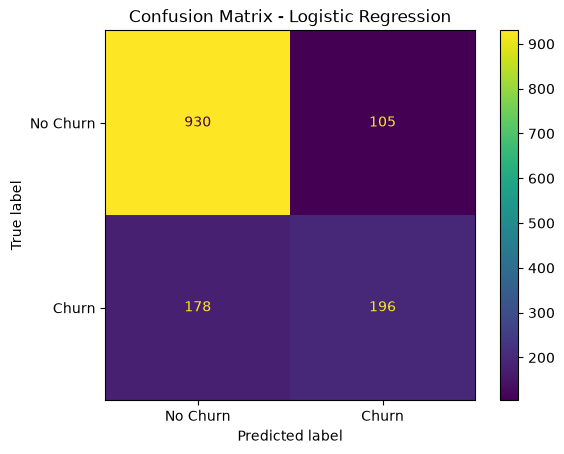

In [37]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("../images/confusion_matrix.png", dpi = 300, bbox_inches ="tight")
plt.show()

## 16. Feature Importance

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
15,internet_service_Fiber optic,1.148674
2,total_charges,0.557000
11,payment_method_Electronic check,0.363463
26,streaming_tv_Yes,0.359732
3,paperless_billing,0.347524
28,streaming_movies_Yes,0.346500
14,multiple_lines_Yes,0.345972
5,senior_citizen,0.142901
12,payment_method_Mailed check,0.078178
6,partner,0.066654


In [39]:
feature_importance.tail(10)

,Feature,Coefficient
16,internet_service_No,-0.163207
7,dependents,-0.205841
13,multiple_lines_No phone service,-0.216794
18,online_security_Yes,-0.310907
24,tech_support_Yes,-0.347604
1,monthly_charges,-0.416383
4,phone_service,-0.524048
8,contract_One year,-0.736522
0,tenure,-1.299275
9,contract_Two year,-1.334224


## 17. Save the Trained Model

In [40]:
import joblib

In [41]:
joblib.dump(model, "../src/churn_model.pkl")

['../src/churn_model.pkl']

In [42]:
joblib.dump(scaler, "../src/scaler.pkl")

['../src/scaler.pkl']

# Day 5 - Model Comparison

## 18. Train a Decision Tree Classifier

In [43]:
from sklearn.tree import DecisionTreeClassifier

In [44]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [45]:
decision_tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [46]:
dt_predictions = decision_tree.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_predictions)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.7211


## 19. Train a Random Forest Classifier

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [50]:
random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [51]:
rf_predictions = random_forest.predict(X_test)

In [52]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.7906


## 20. Compare Model Performance

In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.799148
2,Random Forest,0.790632
1,Decision Tree,0.721079


## 21. Model Accuracy Comparison

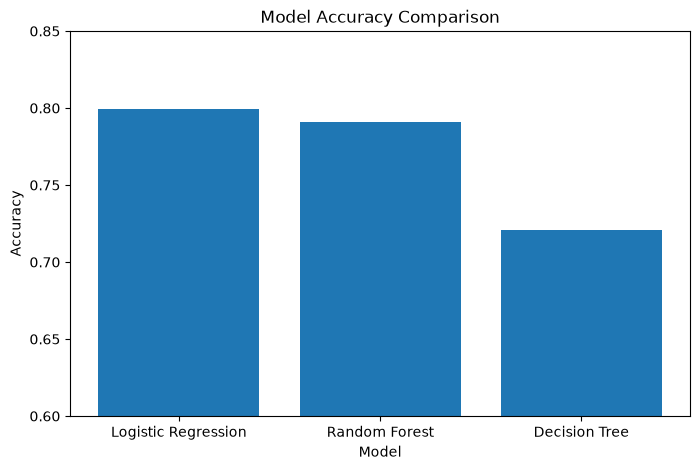

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.6, 0.85)

plt.show()

## 22. Random Forest Feature Importance

In [55]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,total_charges,0.190159
0,tenure,0.179365
1,monthly_charges,0.173122
15,internet_service_Fiber optic,0.043743
11,payment_method_Electronic check,0.032572
9,contract_Two year,0.029562
29,gender_Male,0.027625
3,paperless_billing,0.025797
24,tech_support_Yes,0.023997
6,partner,0.023580


## 23. Feature Importance Visualization

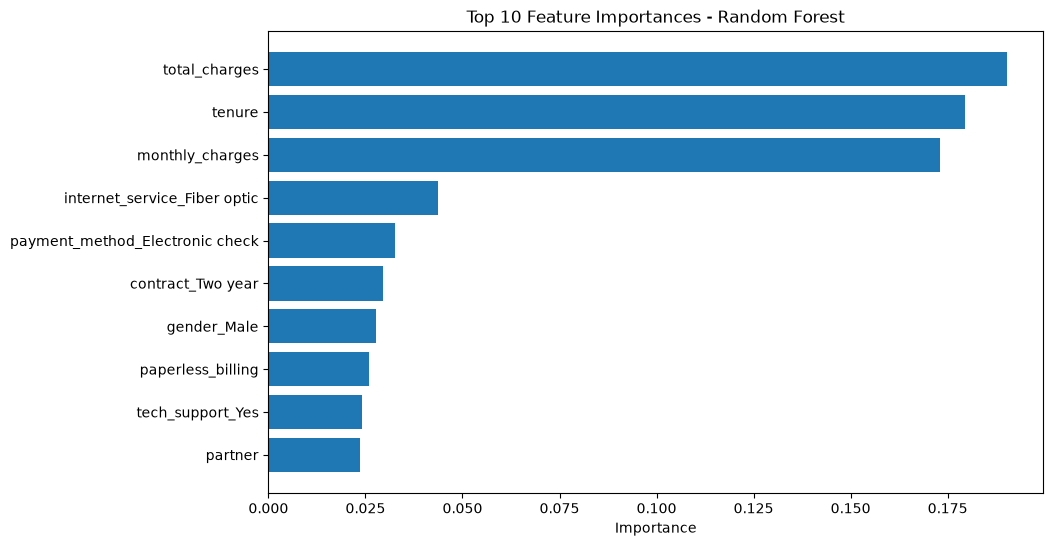

In [56]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

## 24. Conclusion

### Model Performance Summary

Three machine learning models were trained and evaluated on the customer churn dataset.

- Logistic Regression achieved the highest accuracy (**79.91%**) and served as the best-performing model.
- Random Forest achieved **79.06%**, performing competitively while providing feature importance scores.
- Decision Tree achieved **72.11%**, making it the weakest performer among the evaluated models.

The analysis identified **tenure, total charges, monthly charges, internet service type, and contract duration** as the most influential factors associated with customer churn.

These findings can help businesses identify customers at higher risk of leaving and support proactive customer retention strategies.

# 25. Saving DataSet to Folder